# Autonomous Grid Navigation — an AI Solution using Reinforcement Learning and Search

### CIS4049-N *Artificial Intelligence Foundations* — ICA Artefact

**Student:** CUI JIANGKUN &nbsp;|&nbsp; **Student No:** F5743005 &nbsp;|&nbsp; **Module:** CIS4049-N Artificial Intelligence Foundations

---

**The problem.** An autonomous **warehouse delivery robot** must travel from its charging depot
(**S**) to a drop-off point (**G**) across a floor cluttered with storage racks (obstacles) and
slow, congested aisles. We want the robot to reach the goal by the **cheapest** route — not simply
the one with the fewest steps.

**Why this is an *AI* problem.** Finding good action sequences in a state space is one of the oldest
problems in Artificial Intelligence. This notebook solves the *same* navigation task with **two
different families of AI technique** taught in this module and critically compares them:

1. **Reinforcement Learning — tabular Q-learning** (Weeks 5–6). The robot is given **no map**. It
   learns an optimal *policy* purely by trial and error, from the rewards it experiences.
2. **Classical search / planning** (Weeks 7–9). Given a **known map**, we compute the optimal route
   with **Breadth-First Search (BFS)**, **Uniform-Cost Search (UCS / Dijkstra)** and **A\***.

We then compare them on solution quality and computational effort — the "**Search vs Reinforcement
Learning**" theme from the Week 8 lecture.

> The environment is written from scratch (no `gym`/`gymnasium` dependency) so the whole artefact is
> reproducible offline and every line is transparent to the reader.

## 1. Setup
Only standard scientific-Python libraries and the Python standard library are used.

In [12]:
import random
import heapq
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

RANDOM_SEED = 42
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "font.size": 11})
print("Setup complete — numpy", np.__version__, "| pandas", pd.__version__)

Setup complete — numpy 2.0.2 | pandas 2.3.3


## 2. The environment (state space)

The warehouse floor is modelled as a **grid** — the classic *pathing* state space from the module
lectures (states = `(row, col)`, actions = North/South/East/West). Each cell is one of:

| Symbol | Meaning | Cost to enter |
|:---:|:---|:---:|
| `.` | free floor | **1** |
| `~` | congested aisle | **5** |
| `#` | rack / obstacle | *impassable* |
| `S` | start (depot) | 1 |
| `G` | goal (drop-off) | 1 |

Transitions are **deterministic**: an action moves the robot to the adjacent cell, unless that cell is
a wall or off-grid, in which case the robot **stays where it is** (exactly as in the Taxi environment
studied in Week 6). The layout is deliberately designed so that the *shortest* route in **steps** runs
through the expensive congested band, while a slightly longer detour over free floor is **cheaper** —
this is what makes the comparison between step-optimal and cost-optimal methods meaningful.

In [13]:
GRID_LAYOUT = [
    "S....#.....",
    ".###.#.###.",
    ".#~~~..#.#.",
    ".#~~~###.#.",
    ".#~~~....#.",
    ".#~~~.##.#.",
    ".#...##..#.",
    ".#.#....##.",
    "...#.####..",
    "####.....G.",
]
TERRAIN_COST = {".": 1, "~": 5, "S": 1, "G": 1}   # cost of ENTERING a cell
ACTIONS = ["N", "S", "E", "W"]
MOVES   = {"N": (-1, 0), "S": (1, 0), "E": (0, 1), "W": (0, -1)}


class GridWorld:
    '''A deterministic, fully-observable grid-navigation environment.'''

    def __init__(self, layout=GRID_LAYOUT):
        self.grid = [list(row) for row in layout]
        self.n_rows, self.n_cols = len(self.grid), len(self.grid[0])
        self.start = self._find("S")
        self.goal  = self._find("G")
        self.goal_reward  = 50.0    # reward-shaping bonus for reaching the goal
        self.wall_penalty = 10.0    # penalty for bumping into a rack

    def _find(self, symbol):
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                if self.grid[r][c] == symbol:
                    return (r, c)
        raise ValueError(symbol)

    def is_wall(self, cell):   return self.grid[cell[0]][cell[1]] == "#"
    def in_bounds(self, cell): return 0 <= cell[0] < self.n_rows and 0 <= cell[1] < self.n_cols
    def passable(self, cell):  return self.in_bounds(cell) and not self.is_wall(cell)
    def terrain_cost(self, cell): return TERRAIN_COST[self.grid[cell[0]][cell[1]]]

    def neighbours(self, cell):
        '''Passable 4-neighbours as (next_cell, move_cost, action).'''
        out = []
        for a in ACTIONS:
            nxt = (cell[0] + MOVES[a][0], cell[1] + MOVES[a][1])
            if self.passable(nxt):
                out.append((nxt, self.terrain_cost(nxt), a))
        return out

    # --- Reinforcement-Learning interface ---
    def reset(self):
        self.agent = self.start
        return self.agent

    def step(self, action):
        '''Return (next_state, reward, done) after taking `action`.'''
        nxt = (self.agent[0] + MOVES[action][0], self.agent[1] + MOVES[action][1])
        if not self.passable(nxt):                       # blocked -> stay
            return self.agent, -self.wall_penalty, False
        self.agent = nxt
        if nxt == self.goal:                             # reached drop-off
            return nxt, self.goal_reward - self.terrain_cost(nxt), True
        return nxt, -self.terrain_cost(nxt), False       # ordinary move


env = GridWorld()
print(f"Grid: {env.n_rows} x {env.n_cols}  |  start {env.start} -> goal {env.goal}")
print(f"Free floor: {sum(ch in '.SG' for row in env.grid for ch in row)} cells, "
      f"congested: {sum(ch == '~' for row in env.grid for ch in row)} cells, "
      f"walls: {sum(ch == '#' for row in env.grid for ch in row)} cells")

Grid: 10 x 11  |  start (0, 0) -> goal (9, 9)
Free floor: 59 cells, congested: 12 cells, walls: 39 cells


A helper to draw the grid, which we reuse throughout the notebook.

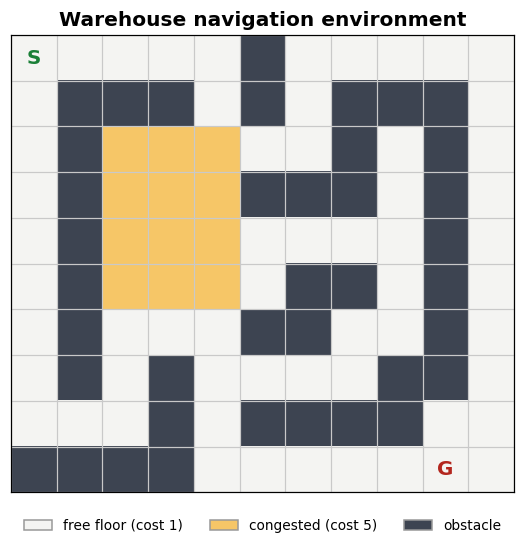

In [14]:
CODE = {".": 0, "S": 0, "G": 0, "~": 1, "#": 2}
CMAP = ListedColormap(["#f4f4f2", "#f6c667", "#3d4451"])   # floor / congested / wall

def grid_codes(env):
    return np.array([[CODE[env.grid[r][c]] for c in range(env.n_cols)]
                     for r in range(env.n_rows)])

def draw_grid(ax, env, title=""):
    ax.imshow(grid_codes(env), cmap=CMAP, vmin=0, vmax=2)
    ax.set_xticks(np.arange(-.5, env.n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-.5, env.n_rows, 1), minor=True)
    ax.grid(which="minor", color="#c9c9c9", linewidth=.8)
    ax.set_xticks([]); ax.set_yticks([]); ax.tick_params(which="both", length=0)
    ax.text(env.start[1], env.start[0], "S", ha="center", va="center",
            fontsize=13, fontweight="bold", color="#1a7f37")
    ax.text(env.goal[1], env.goal[0], "G", ha="center", va="center",
            fontsize=13, fontweight="bold", color="#b3261e")
    if title: ax.set_title(title)

fig, ax = plt.subplots(figsize=(6.0, 5.4))
draw_grid(ax, env, "Warehouse navigation environment")
ax.legend(handles=[Patch(facecolor="#f4f4f2", edgecolor="#999", label="free floor (cost 1)"),
                   Patch(facecolor="#f6c667", edgecolor="#999", label="congested (cost 5)"),
                   Patch(facecolor="#3d4451", edgecolor="#999", label="obstacle")],
          loc="upper center", bbox_to_anchor=(0.5, -0.03), ncol=3, frameon=False, fontsize=9)
plt.show()

## 3. Reinforcement Learning — tabular Q-learning (Weeks 5–6)

The robot does **not** know the map. It learns a **Q-table** `Q(s, a)` — the expected long-term value
of taking action `a` in state `s` — by repeatedly acting and observing rewards. After each transition
`(s, a, r, s')` it applies the **off-policy temporal-difference update**:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,\big[\,r + \gamma\,\max_{a'} Q(s',a') - Q(s,a)\,\big]$$

Actions are chosen **ε-greedily**: with probability ε a random action (*exploration*), otherwise the
current best action (*exploitation*). ε is **annealed** from 1.0 towards 0.05 so the agent explores
early and exploits later — the exploration/exploitation trade-off discussed in the lectures.

In [15]:
def q_learning(env, episodes=1500, alpha=0.1, gamma=0.95,
               epsilon_start=1.0, epsilon_min=0.05, decay=0.995,
               max_steps=200, seed=RANDOM_SEED):
    '''Train a tabular Q-learning agent; return (Q, history).'''
    rng = random.Random(seed)
    # one row of four action-values per cell, all initialised to zero
    Q = {(r, c): {a: 0.0 for a in ACTIONS}
         for r in range(env.n_rows) for c in range(env.n_cols)}
    epsilon = epsilon_start
    rewards, steps = [], []

    for _ in range(episodes):
        s = env.reset()
        total, done = 0.0, False
        for t in range(max_steps):
            # --- epsilon-greedy action selection ---
            if rng.random() < epsilon:
                a = rng.choice(ACTIONS)                 # explore
            else:
                a = max(Q[s], key=Q[s].get)             # exploit
            s2, r, done = env.step(a)
            # --- Q-learning (off-policy TD) update ---
            Q[s][a] += alpha * (r + gamma * max(Q[s2].values()) - Q[s][a])
            s, total = s2, total + r
            if done:
                break
        rewards.append(total); steps.append(t + 1)
        epsilon = max(epsilon_min, epsilon * decay)     # anneal exploration
    return Q, {"rewards": rewards, "steps": steps, "episodes": episodes}


Q, hist = q_learning(env)
print(f"Trained for {hist['episodes']} episodes.")
print(f"Average reward over the last 50 episodes : {np.mean(hist['rewards'][-50:]):.2f}")
print(f"Average steps  over the last 50 episodes : {np.mean(hist['steps'][-50:]):.2f}")

Trained for 1500 episodes.
Average reward over the last 50 episodes : 22.84
Average steps  over the last 50 episodes : 23.14


**Convergence.** Early on the agent wanders for the full 200-step budget and accumulates large negative reward; as the Q-values propagate it rapidly learns to reach the goal in ~22 steps with positive reward.

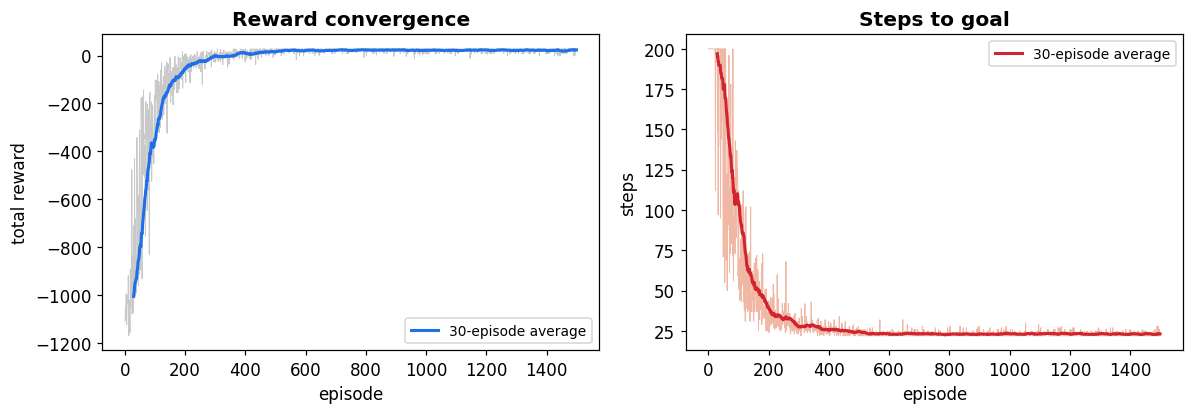

In [16]:
def moving_avg(x, k=30):
    return np.convolve(x, np.ones(k) / k, mode="valid")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
ax[0].plot(hist["rewards"], color="#c9c9c9", lw=.6)
ax[0].plot(np.arange(29, len(hist["rewards"])), moving_avg(hist["rewards"]),
           color="#1f6feb", lw=2, label="30-episode average")
ax[0].set_title("Reward convergence"); ax[0].set_xlabel("episode")
ax[0].set_ylabel("total reward"); ax[0].legend(fontsize=9)
ax[1].plot(hist["steps"], color="#f0b7a4", lw=.6)
ax[1].plot(np.arange(29, len(hist["steps"])), moving_avg(hist["steps"]),
           color="#d1242f", lw=2, label="30-episode average")
ax[1].set_title("Steps to goal"); ax[1].set_xlabel("episode")
ax[1].set_ylabel("steps"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**The learned policy.** Reading the greedy action `argmax_a Q(s,a)` in every cell gives the robot's learned policy. Plotting it over the state values `V(s)=max_a Q(s,a)` shows a smooth value gradient rising towards the goal, with the arrows forming a coherent route to **G**.

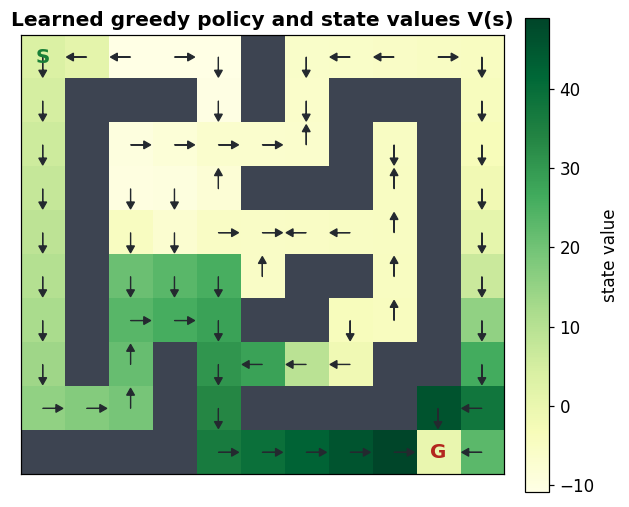

Greedy policy reaches goal: True | steps=22 | path cost=22


In [17]:
def greedy_rollout(env, Q, max_steps=200):
    '''Follow the greedy policy from the start; return (path, cost, reached).'''
    s = env.reset(); path, cost = [s], 0
    for _ in range(max_steps):
        a = max(Q[s], key=Q[s].get)
        nxt = (s[0] + MOVES[a][0], s[1] + MOVES[a][1])
        if not env.passable(nxt):
            break
        cost += env.terrain_cost(nxt); s = nxt; path.append(s)
        if s == env.goal:
            break
    return path, cost, path[-1] == env.goal

# state-value heat-map + greedy-policy arrows
V = np.full((env.n_rows, env.n_cols), np.nan)
for cell, av in Q.items():
    if env.passable(cell):
        V[cell] = max(av.values())

fig, ax = plt.subplots(figsize=(6.2, 5.6))
im = ax.imshow(np.ma.masked_invalid(V), cmap="YlGn")
ax.imshow(np.where(grid_codes(env) == 2, 1, np.nan),
          cmap=ListedColormap(["#3d4451"]), vmin=0, vmax=1)
for cell, av in Q.items():
    if not env.passable(cell) or cell == env.goal:
        continue
    a = max(av, key=av.get)
    ax.arrow(cell[1], cell[0], MOVES[a][1]*0.3, MOVES[a][0]*0.3,
             head_width=0.18, head_length=0.16, fc="#24292f", ec="#24292f", lw=.8)
ax.text(env.start[1], env.start[0], "S", ha="center", va="center", fontsize=13, fontweight="bold", color="#1a7f37")
ax.text(env.goal[1], env.goal[0], "G", ha="center", va="center", fontsize=13, fontweight="bold", color="#b3261e")
ax.set_xticks([]); ax.set_yticks([]); ax.set_title("Learned greedy policy and state values V(s)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="state value")
plt.show()

q_path, q_cost, q_reached = greedy_rollout(env, Q)
print(f"Greedy policy reaches goal: {q_reached} | steps={len(q_path)-1} | path cost={q_cost}")

## 4. Classical search / planning (Weeks 7–9)

Now we give the algorithm the **full map** and search the state space directly. All three algorithms
share the "one queue" structure from the lectures — they differ only in how the frontier is ordered:

* **BFS** — a **FIFO queue**. Expands the shallowest node first, so it is optimal in the **number of
  steps**, but ignores terrain cost.
* **UCS / Dijkstra** — a **priority queue keyed by path cost** `g(n)`. Expands the cheapest node first,
  so it is optimal in **total cost**.
* **A\*** — a priority queue keyed by `f(n) = g(n) + h(n)`, where `h` is the **Manhattan-distance**
  heuristic. It is optimal in cost with an *admissible* heuristic, but reaches the goal after expanding
  far fewer nodes than UCS.

In [18]:
def reconstruct(came_from, goal):
    path, node = [goal], goal
    while came_from.get(node) is not None:
        node = came_from[node]; path.append(node)
    return path[::-1]

def bfs(env):
    '''Breadth-First Search — FIFO frontier; optimal in number of steps.'''
    frontier = deque([env.start]); came_from = {env.start: None}; expanded = 0
    while frontier:
        node = frontier.popleft(); expanded += 1
        if node == env.goal:
            path = reconstruct(came_from, env.goal)
            return {"path": path, "cost": sum(env.terrain_cost(c) for c in path[1:]),
                    "steps": len(path)-1, "expanded": expanded}
        for nxt, _w, _a in env.neighbours(node):
            if nxt not in came_from:
                came_from[nxt] = node; frontier.append(nxt)

def uniform_cost_search(env):
    '''Uniform-Cost Search / Dijkstra — cheapest-first; optimal in cost.'''
    frontier = [(0, env.start)]; came_from = {env.start: None}
    best = {env.start: 0}; expanded = 0
    while frontier:
        cost, node = heapq.heappop(frontier)
        if node == env.goal:
            return {"path": reconstruct(came_from, env.goal), "cost": cost,
                    "steps": len(reconstruct(came_from, env.goal))-1, "expanded": expanded}
        if cost > best.get(node, float("inf")): continue
        expanded += 1
        for nxt, w, _a in env.neighbours(node):
            nc = cost + w
            if nc < best.get(nxt, float("inf")):
                best[nxt] = nc; came_from[nxt] = node; heapq.heappush(frontier, (nc, nxt))

def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def a_star(env):
    '''A* — orders the frontier by f(n)=g(n)+h(n) with an admissible heuristic.'''
    start, goal = env.start, env.goal
    frontier = [(manhattan(start, goal), 0, start)]; came_from = {start: None}
    best = {start: 0}; expanded = 0
    while frontier:
        _f, g, node = heapq.heappop(frontier)
        if node == goal:
            return {"path": reconstruct(came_from, goal), "cost": g,
                    "steps": len(reconstruct(came_from, goal))-1, "expanded": expanded}
        if g > best.get(node, float("inf")): continue
        expanded += 1
        for nxt, w, _a in env.neighbours(node):
            ng = g + w
            if ng < best.get(nxt, float("inf")):
                best[nxt] = ng; came_from[nxt] = node
                heapq.heappush(frontier, (ng + manhattan(nxt, goal), ng, nxt))

res_bfs = bfs(env); res_ucs = uniform_cost_search(env); res_astar = a_star(env)
for name, r in [("BFS", res_bfs), ("UCS/Dijkstra", res_ucs), ("A*", res_astar)]:
    print(f"{name:14s} cost={r['cost']:3d}  steps={r['steps']:3d}  nodes expanded={r['expanded']:3d}")

BFS            cost= 34  steps= 18  nodes expanded= 64
UCS/Dijkstra   cost= 22  steps= 22  nodes expanded= 59
A*             cost= 22  steps= 22  nodes expanded= 33


## 5. Critical comparison — Search vs Reinforcement Learning

We now place all four solutions side by side. The three panels below show the routes each paradigm
chose; the table and bar charts quantify the trade-offs.

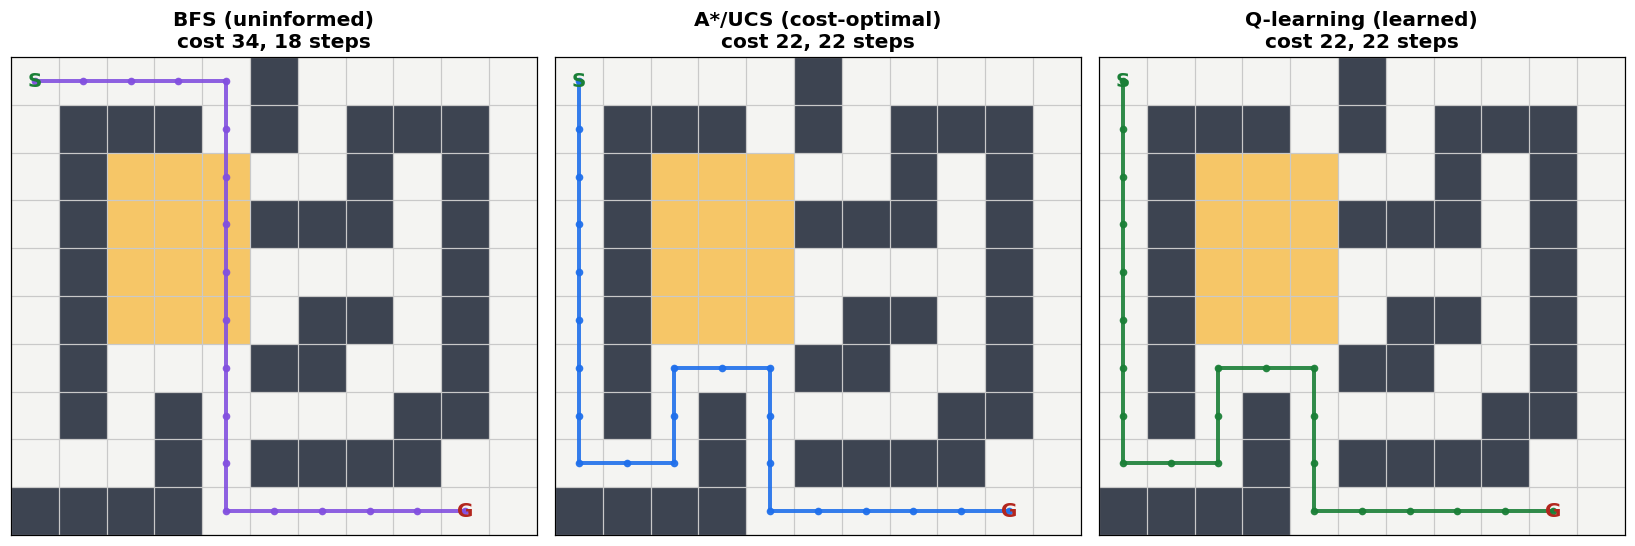

In [19]:
def draw_path(ax, path, colour):
    ax.plot([p[1] for p in path], [p[0] for p in path], color=colour,
            lw=2.6, marker="o", ms=4, alpha=.9)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.1))
draw_grid(axes[0], env, f"BFS (uninformed)\ncost {res_bfs['cost']}, {res_bfs['steps']} steps")
draw_path(axes[0], res_bfs["path"], "#8250df")
draw_grid(axes[1], env, f"A*/UCS (cost-optimal)\ncost {res_astar['cost']}, {res_astar['steps']} steps")
draw_path(axes[1], res_astar["path"], "#1f6feb")
draw_grid(axes[2], env, f"Q-learning (learned)\ncost {q_cost}, {len(q_path)-1} steps")
draw_path(axes[2], q_path, "#1a7f37")
plt.tight_layout(); plt.show()

The summary table collects the headline numbers. *Model needed?* records whether the method requires a known map of the environment in advance.

In [20]:
summary = pd.DataFrame([
    {"Method": "BFS (uninformed)",       "Paradigm": "Search",  "Path cost": res_bfs["cost"],
     "Steps": res_bfs["steps"],   "Nodes expanded": res_bfs["expanded"],   "Cost-optimal": "No",
     "Model needed?": "Yes"},
    {"Method": "UCS / Dijkstra",         "Paradigm": "Search",  "Path cost": res_ucs["cost"],
     "Steps": res_ucs["steps"],   "Nodes expanded": res_ucs["expanded"],   "Cost-optimal": "Yes",
     "Model needed?": "Yes"},
    {"Method": "A* (informed)",          "Paradigm": "Search",  "Path cost": res_astar["cost"],
     "Steps": res_astar["steps"], "Nodes expanded": res_astar["expanded"], "Cost-optimal": "Yes",
     "Model needed?": "Yes"},
    {"Method": "Q-learning (RL)",        "Paradigm": "Learning","Path cost": q_cost,
     "Steps": len(q_path)-1,      "Nodes expanded": "—",                   "Cost-optimal": "Yes*",
     "Model needed?": "No"},
])
summary

,Method,Paradigm,Path cost,Steps,Nodes expanded,Cost-optimal,Model needed?
0,BFS (uninformed),Search,34,18,64,No,Yes
1,UCS / Dijkstra,Search,22,22,59,Yes,Yes
2,A* (informed),Search,22,22,33,Yes,Yes
3,Q-learning (RL),Learning,22,22,—,Yes*,No


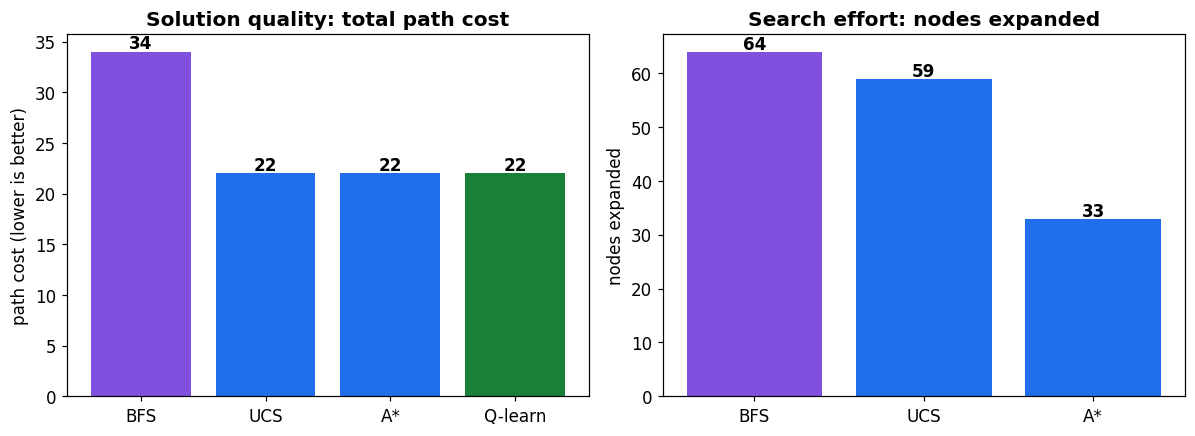

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
methods = ["BFS", "UCS", "A*", "Q-learn"]
costs   = [res_bfs["cost"], res_ucs["cost"], res_astar["cost"], q_cost]
b0 = ax[0].bar(methods, costs, color=["#8250df", "#1f6feb", "#1f6feb", "#1a7f37"])
ax[0].set_title("Solution quality: total path cost"); ax[0].set_ylabel("path cost (lower is better)")
for b, v in zip(b0, costs):
    ax[0].text(b.get_x()+b.get_width()/2, v+.3, str(v), ha="center", fontweight="bold")
sm, se = ["BFS", "UCS", "A*"], [res_bfs["expanded"], res_ucs["expanded"], res_astar["expanded"]]
b1 = ax[1].bar(sm, se, color=["#8250df", "#1f6feb", "#1f6feb"])
ax[1].set_title("Search effort: nodes expanded"); ax[1].set_ylabel("nodes expanded")
for b, v in zip(b1, se):
    ax[1].text(b.get_x()+b.get_width()/2, v+.5, str(v), ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

## 6. Experimental validation

We assert the properties predicted by the theory, so the notebook **fails loudly** if the
implementation is wrong.

In [22]:
checks = {
    "BFS uses the fewest steps":                res_bfs["steps"] <= res_ucs["steps"],
    "BFS is NOT cost-optimal (ignores terrain)": res_bfs["cost"] > res_ucs["cost"],
    "A* matches UCS cost (both optimal)":        res_astar["cost"] == res_ucs["cost"],
    "A* expands fewer nodes than UCS":           res_astar["expanded"] < res_ucs["expanded"],
    "Q-learning converged to the optimal cost":  q_cost == res_ucs["cost"],
}
for name, ok in checks.items():
    print(f"[{'PASS' if ok else 'FAIL'}]  {name}")
assert all(checks.values()), "a validation check failed!"
print("\nAll validation checks passed.")

[PASS]  BFS uses the fewest steps
[PASS]  BFS is NOT cost-optimal (ignores terrain)
[PASS]  A* matches UCS cost (both optimal)
[PASS]  A* expands fewer nodes than UCS
[PASS]  Q-learning converged to the optimal cost

All validation checks passed.


## 7. Conclusions

Both AI paradigms solve the navigation task and **agree on the optimal-cost route (cost 22)**, which
cross-validates the two very different implementations. Their assumptions and costs differ sharply:

* **Classical search** is fast and exact **when a reliable map is available**. **A\*** is the clear
  winner here — the admissible Manhattan heuristic lets it reach the optimum while expanding roughly
  **half** the nodes of uninformed UCS. **BFS** is a cautionary tale: it returns the *shortest* route
  but a **55% more expensive** one, because it optimises the wrong objective (steps, not cost).
* **Reinforcement learning (Q-learning)** needs **no map** — it discovers the same optimal policy from
  experience alone. The price is sample cost (~1,500 episodes of trial and error) and the fact that
  optimality is *empirical* rather than guaranteed; states far from the optimal route stay
  under-explored, so their learned values are noisy.

The practical lesson mirrors the Week 8 "Search vs RL" discussion: **use search when you have a model
of the world, and reinforcement learning when you must learn the world by interacting with it.** In a
real warehouse — with unknown, changing layouts and stochastic outcomes — a learning agent (or a
hybrid that plans with search and adapts with RL) is the more robust choice.